In [1]:
# CELL 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

In [3]:
# CELL 2: Loading your CSV and Encoding Categorical Values
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Dosyanı yükle (Dosya adının doğru olduğundan emin ol)
# Eğer dosyan farklı bir isimdeyse burayı değiştir:
df = pd.read_csv('diabetes_risk_prediction_dataset.csv') 

# 2. Verideki metinleri (Yes/No, Male/Female) sayısallaştıralım
# LabelEncoder her sütundaki kategorik veriyi 0 ve 1'e çevirir.
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object': # Eğer sütun metin içeriyorsa
        df[column] = le.fit_transform(df[column])

# 3. Hedef değişkeni (Target) ve özellikleri (Features) ayır
# Veri setinde hedef sütun adı genellikle 'class' veya 'result' olur.
# Lütfen CSV dosmandaki hedef sütun ismini buraya yaz:
target_column = 'class' 

X = df.drop(columns=[target_column])
y = df[target_column]

# 4. Eğitim ve Test setine ayır (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Veri başarıyla yüklendi: {df.shape[0]} satır, {df.shape[1]} sütun.")
print(f"Eğitim seti: {X_train.shape[0]} | Test seti: {X_test.shape[0]}")
df.head() # İlk 5 satırı kontrol edelim

Veri başarıyla yüklendi: 520 satır, 17 sütun.
Eğitim seti: 416 | Test seti: 104


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [5]:
# CELL 3: Pipeline Creation and Model Comparison

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogReg (L2)': LogisticRegression(penalty='l2', C=1.0, solver='liblinear', random_state=42),
    'Naive Bayes': GaussianNB(),
    'Linear SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42)
}

def build_pipeline(classifier):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        # SelectKBest: En önemli 10 özelliği seçiyoruz (küçük veri setinde gürültüyü azaltır)
        ('feature_selection', SelectKBest(score_func=chi2, k=10)), 
        ('scaler', StandardScaler()),
        ('classifier', classifier)
    ])

results = []

for name, model in models.items():
    pipeline = build_pipeline(model)
    scoring = ['accuracy', 'precision', 'recall', 'f1']
    cv_scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)
    
    results.append({
        'Model': name,
        'Accuracy': cv_scores['test_accuracy'].mean(),
        'Recall': cv_scores['test_recall'].mean(), # Tıbbi veri olduğu için odak noktamız
        'F1-Score': cv_scores['test_f1'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by='Recall', ascending=False)
print(results_df)

           Model  Accuracy    Recall  F1-Score
3  Decision Tree  0.918216  0.945249  0.934672
0    LogReg (L2)  0.908577  0.921644  0.924942
2     Linear SVM  0.884538  0.913801  0.906298
1    Naive Bayes  0.877309  0.906259  0.901224


In [7]:
# CELL 4: Hyperparameter Tuning (Logistic Regression)

# We want to tune Logistic Regression to maximize Recall while keeping L2 regularization strong
log_reg_pipeline = build_pipeline(LogisticRegression(penalty='l2', solver='liblinear', random_state=42))

# Define parameter grid: smaller C = stronger regularization (prevents overfitting)
param_grid = {
    'classifier__C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'feature_selection__k': [6, 8, 'all'] # Also tune the number of selected features
}

# Emphasize recall during grid search
grid_search = GridSearchCV(
    log_reg_pipeline, 
    param_grid, 
    cv=cv, 
    scoring='recall', # Optimize for Recall
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters for LogReg: {grid_search.best_params_}")
print(f"Best CV Recall Score: {grid_search.best_score_:.4f}")

best_log_reg = grid_search.best_estimator_

Best Parameters for LogReg: {'classifier__C': 5.0, 'feature_selection__k': 6}
Best CV Recall Score: 0.9452


In [9]:
# CELL 5: Soft Voting Ensemble

# Extract the tuned Logistic Regression model from the grid search
tuned_log_reg = grid_search.best_estimator_.named_steps['classifier']

# Re-create pipeline components using the best parameters found
best_k = grid_search.best_params_['feature_selection__k']

ensemble_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('feature_selection', SelectKBest(score_func=chi2, k=best_k)),
    ('scaler', StandardScaler()),
    ('classifier', VotingClassifier(
        estimators=[
            ('lr', tuned_log_reg),
            ('nb', GaussianNB())
        ],
        voting='soft' # Uses predicted probabilities to make final decision
    ))
])

# Fit the ensemble on the entire training set
ensemble_pipeline.fit(X_train, y_train)
print("Ensemble Model (Tuned LogReg + Naive Bayes) successfully trained.")

Ensemble Model (Tuned LogReg + Naive Bayes) successfully trained.


--- FINAL EVALUATION ON HOLD-OUT TEST SET ---
Accuracy:  0.9327
Precision: 0.9672
Recall:    0.9219 <-- (Critical Metric)
F1-Score:  0.9440

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92        40
           1       0.97      0.92      0.94        64

    accuracy                           0.93       104
   macro avg       0.93      0.94      0.93       104
weighted avg       0.94      0.93      0.93       104



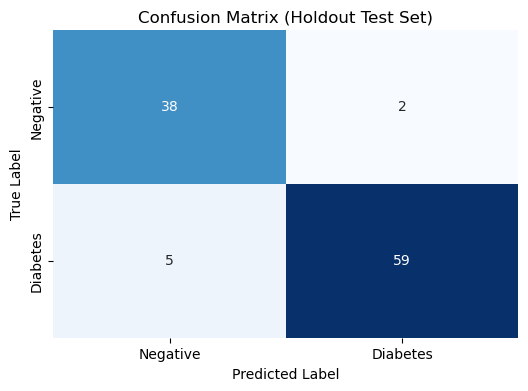

In [11]:
# CELL 6: Final Evaluation on Holdout Test Set

# Predict on test data using the Ensemble Model
y_pred = ensemble_pipeline.predict(X_test)

# Calculate final metrics
print("--- FINAL EVALUATION ON HOLD-OUT TEST SET ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f} <-- (Critical Metric)")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Diabetes'],
            yticklabels=['Negative', 'Diabetes'])
plt.title('Confusion Matrix (Holdout Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()